# 공공기관식 문화시설 접근성 지표 재구현

공공기관 접근성 지표의 핵심은 격자에서 가장 가까운 시설까지의 도로망 기반 최단거리를 계산하고, 기준거리 안에 들어오는 인구 비율을 행정구역 단위로 집계하는 것이다.

이 노트북에서는 해당 방식을 문화누리카드 가맹점 자료에 적용하되, 서비스권역 내 인구는 일반 인구가 아니라 `문화누리대상자_추정_인구수`를 기준으로 산정한다.

## 접근성 지표 산식

격자 `i`, 문화시설 `j`, 중분류 `k`, 행정동 `d`에 대해 다음과 같이 정의한다.

$$
A_{i,k} = \min_{j \in C_k} D_{ij}
$$

$$
D_{ij} = S_i^g + N(n_i, n_j) + S_j^f
$$

$$
I_{i,k} = \mathbf{1}(A_{i,k} \leq 10{,}000)
$$

$$
R_{d,k} =
\frac{\sum_{i \in d} M_i I_{i,k}}
{\sum_{i \in d} M_i}
\times 100
$$

- $A_{i,k}$: 격자 `i`에서 중분류 `k` 시설까지의 최근접 접근거리
- $C_k$: 중분류 `k`에 속하는 문화시설 집합
- $S_i^g$: 격자 중심점에서 도로망 node까지의 스냅거리
- $N(n_i, n_j)$: 도로망 node 간 최단거리
- $S_j^f$: 문화시설 POI에서 도로망 node까지의 스냅거리
- $M_i$: 격자별 문화누리대상자 추정 인구수
- $R_{d,k}$: 행정동 `d`의 중분류 `k` 10km 서비스권역 내 문화누리대상자 비율

정부식 최근접 시설 접근성의 형태는 유지하되, 우리 프로젝트의 분류별 접근성 지표와 비교할 수 있도록 중분류별로 최근접 시설을 따로 계산한다.

## 패키지 및 경로 설정

In [1]:
from pathlib import Path
import warnings

import geopandas as gpd
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
from matplotlib.colors import LinearSegmentedColormap
from scipy.spatial import cKDTree

warnings.filterwarnings("ignore", category=UserWarning)

BASE_PATH = Path.cwd()
while BASE_PATH.name != "oracle_mnc_project" and BASE_PATH.parent != BASE_PATH:
    BASE_PATH = BASE_PATH.parent

DATA_PATH = BASE_PATH / "analysis_table" / "data"
INPUT_PATH = DATA_PATH / "input"
OUTPUT_PATH = DATA_PATH / "output"
NETWORK_PATH = INPUT_PATH / "network"
KTDB_PATH = NETWORK_PATH / "ktdb_transport_network"
ACCESS_PATH = BASE_PATH / "notebooks" / "access"
NOTEBOOK_OUTPUT_PATH = ACCESS_PATH / "OUTPUT"
IMAGE_PATH = ACCESS_PATH / "IMAGE"

NOTEBOOK_OUTPUT_PATH.mkdir(parents=True, exist_ok=True)
IMAGE_PATH.mkdir(parents=True, exist_ok=True)

GRID_PATH = OUTPUT_PATH / "서울시_100m_문화누리추정인구수.gpkg"
STORE_PATH = OUTPUT_PATH / "서울시_문화누리카드_가맹점_2026.gpkg"
BOUND_PATH = OUTPUT_PATH / "서울시_시군구_행정동_경계.gpkg"

NODE_PATH = next(KTDB_PATH.rglob("2025node.txt"))
LINK_PATH = next(KTDB_PATH.rglob("2025link.txt"))

SERVICE_LIMIT_M = 10_000
SEOUL_BUFFER_M = 2_000
ROAD_LINK_TYPES = list(range(101, 109))

facility_mid_categories = [
    "도서", "문화체험", "음악", "영상", "체육시설", "체육용품",
    "미술", "공연", "스포츠관람", "관광지"
]

salmon_cmap = LinearSegmentedColormap.from_list(
    "salmon_cmap",
    ["#fff7f3", "#fdd0c2", "#f99985", "#ef6548", "#b30000"]
)

print(f"프로젝트 경로: {BASE_PATH}")
print(f"격자 데이터: {GRID_PATH.name}")
print(f"가맹점 데이터: {STORE_PATH.name}")
print(f"행정동 경계 데이터: {BOUND_PATH.name}")
print(f"KTDB node: {NODE_PATH.name}")
print(f"KTDB link: {LINK_PATH.name}")
print(f"산출물 데이터 저장 경로: {NOTEBOOK_OUTPUT_PATH}")
print(f"산출물 이미지 저장 경로: {IMAGE_PATH}")

프로젝트 경로: C:\project\oracle_mnc_project
격자 데이터: 서울시_100m_문화누리추정인구수.gpkg
가맹점 데이터: 서울시_문화누리카드_가맹점_2026.gpkg
행정동 경계 데이터: 서울시_시군구_행정동_경계.gpkg
KTDB node: 2025node.txt
KTDB link: 2025link.txt
산출물 데이터 저장 경로: C:\project\oracle_mnc_project\notebooks\access\OUTPUT
산출물 이미지 저장 경로: C:\project\oracle_mnc_project\notebooks\access\IMAGE


## 데이터 불러오기 및 기본 품질 점검

격자별 문화누리대상자 추정 테이블, 문화누리카드 가맹점 POI, 행정동 경계 자료를 불러온다. 이후 분석 키(`GRID_CD`, `가맹점_ID`)의 중복, 핵심 칼럼 결측, 좌표계를 확인해 이후 공간결합과 네트워크 분석이 가능한 상태인지 점검한다.

In [2]:
grid = gpd.read_file(GRID_PATH)
store = gpd.read_file(STORE_PATH)
bound = gpd.read_file(BOUND_PATH)

print(f"격자 구조: {grid.shape}")
print(f"격자 CRS: {grid.crs}")
print(f"격자 geometry type: {grid.geometry.geom_type.unique()}")
print(f"격자 GRID_CD 중복: {grid['GRID_CD'].duplicated().sum()}")
print(f"격자 문화누리대상자 추정 인구수 결측: {grid['문화누리대상자_추정_인구수'].isna().sum()}")
print(f"격자 문화누리대상자 추정 인구수 음수: {(grid['문화누리대상자_추정_인구수'] < 0).sum()}")

print("\n가맹점 구조:", store.shape)
print(f"가맹점 CRS: {store.crs}")
print(f"가맹점 geometry type: {store.geometry.geom_type.unique()}")
print(f"가맹점_ID 중복: {store['가맹점_ID'].duplicated().sum()}")
print(f"가맹점 핵심 칼럼 결측")
print(store[['가맹점_ID', '가맹점명', '시군구', '중분류', '소분류', 'geometry']].isna().sum())

print("\n행정동 경계 구조:", bound.shape)
print(f"행정동 경계 CRS: {bound.crs}")
print(f"행정동 수: {bound[['시군구', '행정동']].drop_duplicates().shape[0]}")

display(grid.head())
display(store.head())

격자 구조: (60528, 14)
격자 CRS: EPSG:5179
격자 geometry type: <ArrowStringArray>
['Polygon']
Length: 1, dtype: str
격자 GRID_CD 중복: 0
격자 문화누리대상자 추정 인구수 결측: 0
격자 문화누리대상자 추정 인구수 음수: 0

가맹점 구조: (4702, 17)
가맹점 CRS: EPSG:5179
가맹점 geometry type: <ArrowStringArray>
['Point']
Length: 1, dtype: str
가맹점_ID 중복: 0
가맹점 핵심 칼럼 결측
가맹점_ID      0
가맹점명        0
시군구         0
중분류         0
소분류         0
geometry    0
dtype: int64

행정동 경계 구조: (426, 4)
행정동 경계 CRS: EPSG:5186
행정동 수: 426


,GRID_CD,행정동코드,시군구,행정동,중심점_x,중심점_y,원본_인구수,주거면적,주택수,공시지가,추정_인구수,문화누리대상자_추정_인구수,GRID_CD_500,geometry
0,다사603367,11220670,서초구,양재2동,960350.0,1936750.0,0.0,0.0,0.0,21500.000000,0,0,다사60a36b,"POLYGON ((960300 1936700, 960300 1936800, 9604..."
1,다사604367,11220670,서초구,양재2동,960450.0,1936750.0,0.0,0.0,0.0,21949.995000,0,0,다사60a36b,"POLYGON ((960400 1936700, 960400 1936800, 9605..."
2,다사605367,11220670,서초구,양재2동,960550.0,1936750.0,0.0,0.0,0.0,30233.336667,0,0,다사60b36b,"POLYGON ((960500 1936700, 960500 1936800, 9606..."
3,다사615367,11220680,서초구,내곡동,961550.0,1936750.0,0.0,0.0,0.0,77118.103333,0,0,다사61b36b,"POLYGON ((961500 1936700, 961500 1936800, 9616..."
4,다사602368,11220670,서초구,양재2동,960250.0,1936850.0,0.0,0.0,0.0,21699.990000,0,0,다사60a36b,"POLYGON ((960200 1936800, 960200 1936900, 9603..."


,가맹점_ID,가맹점명,시군구,주소,위도,경도,대분류,중분류,소분류,전화결제,장애인친화시설,찾아가는문화서비스,이용정보,연관검색어,이용분류_상세내용,URL,geometry
0,STORE_00001,(주) 드림네트웍스투어,강남구,서울 강남구 테헤란로 33길 18서울철강빌딩 5층 531호,37.502965,127.039322,관광,여행사,여행사,0,0,0,NaN,#관광#여행사#국내여행#국내여행사#(주) 드림네트웍스투어,NaN,NaN,POINT (959282.133 1944954.925)
1,STORE_00002,(주) 보배렌트카,강남구,서울 강남구 광평로10길 50 2층 42호 보배렌트카,37.481063,127.083253,관광,교통수단,렌터카,0,0,0,NaN,#관광#교통수단#렌터카#렌트#(주) 보배렌트카,NaN,NaN,POINT (963154.316 1942506.922)
2,STORE_00003,(주) 에이치렌터카,강남구,서울 강남구 학동로 342 7층 723호,37.516751,127.040857,관광,교통수단,렌터카,0,0,0,NaN,#관광#교통수단#렌터카#렌트#(주) 에이치렌터카,NaN,NaN,POINT (959425.27 1946483.677)
3,STORE_00004,(주)굿네이버트래블,강남구,서울특별시 강남구 테헤란로 406 샹제리제센터 A동 14080호,37.504388,127.049989,관광,여행사,여행사,0,0,0,저희 굿네이버트래블은 그동안의 축적된 여행업의 경험으로 지방 또는 여행을 자주 접하...,#관광#여행#나드리#축제#페스타#문화#공연#스포츠,NaN,NaN,POINT (960225.742 1945108.28)
4,STORE_00005,(주)대명네트웍스,강남구,서울 강남구 테헤란로 222,37.501623,127.040756,관광,여행사,여행사,0,0,0,NaN,#관광#여행사#국내여행#국내여행사#(주)대명네트웍스,NaN,NaN,POINT (959408.154 1944805.419)


## 문화시설 범위 설정

우리 프로젝트에서 접근성 분석 대상으로 정의한 방문형 문화누리 가맹점 중분류만 남긴다.
이후 최근접 시설 접근거리는 전체 통합값이 아니라 중분류별로 따로 계산한다.

In [3]:
store_facility = store[
    store["중분류"].isin(facility_mid_categories)
].copy()

print(f"전체 문화누리 가맹점 수: {len(store):,}")
print(f"문화시설 접근성 분석 대상 가맹점 수: {len(store_facility):,}")
print(f"제외 가맹점 수: {len(store) - len(store_facility):,}")
print("\n분석 대상 중분류 분포")
print(store_facility["중분류"].value_counts())

display(store_facility[["가맹점_ID", "가맹점명", "시군구", "대분류", "중분류", "소분류"]].head())

전체 문화누리 가맹점 수: 4,702
문화시설 접근성 분석 대상 가맹점 수: 4,282
제외 가맹점 수: 420

분석 대상 중분류 분포
중분류
체육시설     1262
미술        876
도서        654
문화체험      621
체육용품      344
공연        187
음악        150
영상        117
관광지        53
스포츠관람      18
Name: count, dtype: int64


,가맹점_ID,가맹점명,시군구,대분류,중분류,소분류
6,STORE_00007,(주)민음북스,강남구,문화,도서,도서
7,STORE_00008,(주)서울오션아쿠아리움 (코엑스아쿠아리움),강남구,관광,관광지,테마파크
8,STORE_00009,(주)석세스파트너,강남구,문화,도서,도서
9,STORE_00010,(주)술술,강남구,문화,문화체험,문화체험
10,STORE_00011,(주)아이스타미디어컴퍼니,강남구,문화,공연,공연


## KTDB 도로망 node/link 불러오기

KTDB `node`는 교통망의 지점, `link`는 지점과 지점을 연결하는 구간이다. 원자료 첫 줄은 메타 정보이므로 제외하고 읽으며, `Length`는 km 단위로 제공되기 때문에 접근성 기준거리와 맞추기 위해 m 단위 `length_m`으로 변환한다.

In [4]:
# KTDB node/link txt는 첫 줄이 메타 정보이므로 skiprows=1로 제외한다.
node = pd.read_csv(
    NODE_PATH,
    sep=r"\s+",
    skiprows=1,
    header=None,
    names=["record_type", "node_id", "x", "y"],
    engine="python"
).drop(columns="record_type")

link = pd.read_csv(
    LINK_PATH,
    sep=r"\s+",
    skiprows=1,
    header=None,
    names=[
        "record_type", "from_node", "to_node", "length_km", "mode_code",
        "link_type", "lane", "capacity", "speed", "vdf", "cost"
    ],
    engine="python"
).drop(columns="record_type")

node["node_id"] = pd.to_numeric(node["node_id"], errors="coerce").astype("int64")
node["x"] = pd.to_numeric(node["x"], errors="coerce")
node["y"] = pd.to_numeric(node["y"], errors="coerce")

for col in ["from_node", "to_node", "length_km", "link_type", "lane", "capacity", "speed", "vdf", "cost"]:
    link[col] = pd.to_numeric(link[col], errors="coerce")

link = link.dropna(subset=["from_node", "to_node", "length_km"]).copy()
link["from_node"] = link["from_node"].astype("int64")
link["to_node"] = link["to_node"].astype("int64")
link["length_m"] = link["length_km"] * 1000

print(f"KTDB node 구조: {node.shape}")
print(f"KTDB link 구조: {link.shape}")
print(f"node_id 중복: {node['node_id'].duplicated().sum()}")
print(f"from_node-to_node 중복: {link[['from_node', 'to_node']].duplicated().sum()}")
print(f"length_m 결측: {link['length_m'].isna().sum()}")
print(f"length_m 0 이하: {(link['length_m'] <= 0).sum()}")
print("\nlink_type 분포")
print(link["link_type"].value_counts().sort_index())

display(node.head())
display(link.head())

KTDB node 구조: (156405, 3)
KTDB link 구조: (339900, 11)
node_id 중복: 0
from_node-to_node 중복: 0
length_m 결측: 0
length_m 0 이하: 0

link_type 분포
link_type
101      5714
102      1811
103     43398
104     75749
105     12879
106     25772
107    144769
108      8318
200      4601
201       675
300      1748
301      2774
302       722
400      1902
401       186
402        34
999      8848
Name: count, dtype: int64


,node_id,x,y
0,1,309672.531,553998.188
1,2,309409.656,552692.938
2,3,310216.594,554550.188
3,4,308141.094,555991.063
4,5,309032.813,556487.813


,from_node,to_node,length_km,mode_code,link_type,lane,capacity,speed,vdf,cost,length_m
0,1,202920,0.5,atpsxgmluc,999,9.9,35,20.0,9999,0,500.0
1,1,203573,0.5,atpsxgmluc,999,9.9,35,20.0,9999,0,500.0
2,1,203574,0.5,atpsxgmluc,999,9.9,35,20.0,9999,0,500.0
3,1,203575,0.5,atpsxgmluc,999,9.9,35,20.0,9999,0,500.0
4,2,202967,0.5,atpsxgmluc,999,9.9,35,20.0,9999,0,500.0


## KTDB 좌표계 변환 및 서울권 도로망 추출

KTDB 좌표는 KATEC 계열 좌표로 해석한 뒤 프로젝트 기준 좌표계인 EPSG:5179로 변환한다. 서울 경계부 이동이 끊기지 않도록 서울 외곽경계에 2km 버퍼를 적용하고, 공공기관식 차량 10km 지표 재현을 위해 `link_type` 101~108의 일반 도로 링크만 사용한다.

서울 2km 버퍼 내부 node 수: 34,321
도로망 분석용 node 수: 32,651
전체 link 수: 339,900
일반 도로 link_type 101~108 필터 후 link 수: 318,410
서울권 도로망 link 수: 63,510
도로망 node geometry 결측: 0

서울권 도로망 link_type 분포
link_type
101      394
102      779
103     4469
104    46785
105      313
106      168
107     9319
108     1283
Name: count, dtype: int64

분석 제외 link_type 분포
link_type
200    4601
201     675
300    1748
301    2774
302     722
400    1902
401     186
402      34
999    8848
Name: count, dtype: int64


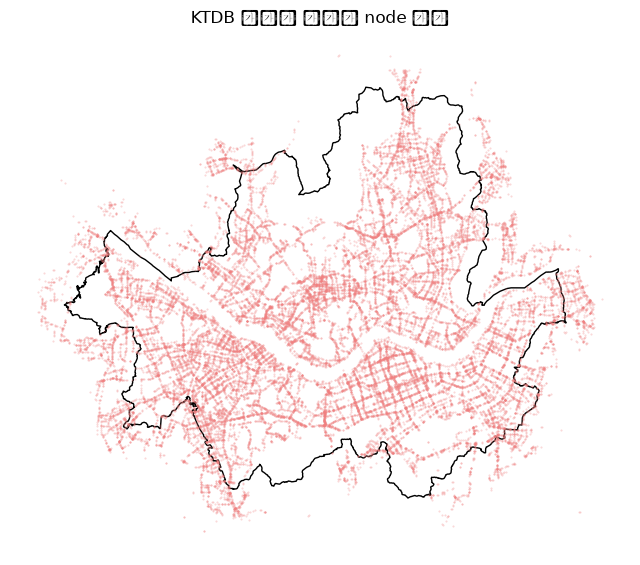

In [5]:
# KTDB 원자료 좌표는 KATEC 계열 좌표로 해석하고, 프로젝트 공간자료와 맞추기 위해 EPSG:5179로 변환한다.
ktdb_crs = (
    "+proj=tmerc +lat_0=38 +lon_0=128 +k=0.9999 "
    "+x_0=400000 +y_0=600000 +ellps=bessel "
    "+towgs84=-146.43,507.89,681.46 +units=m +no_defs"
)

node_gdf = gpd.GeoDataFrame(
    node.copy(),
    geometry=gpd.points_from_xy(node["x"], node["y"]),
    crs=ktdb_crs
).to_crs("EPSG:5179")

seoul_bound_5179 = bound.to_crs("EPSG:5179").dissolve()[["geometry"]].reset_index(drop=True)
seoul_buffer_5179 = seoul_bound_5179.copy()
seoul_buffer_5179["geometry"] = seoul_buffer_5179.geometry.buffer(SEOUL_BUFFER_M)

node_in_buffer = gpd.sjoin(
    node_gdf,
    seoul_buffer_5179[["geometry"]],
    how="inner",
    predicate="within"
).drop(columns="index_right", errors="ignore")

# 공공기관식 차량 10km 지표 재현을 위해 일반 도로 링크(101~108)만 사용한다.
# 200번대는 버스시설, 300번대는 지하철, 400번대는 지역간철도 링크이므로 차량 도로망에서 제외한다.
link_road = link[
    (link["length_m"] > 0) &
    (link["link_type"].isin(ROAD_LINK_TYPES))
].copy()

buffer_node_ids = set(node_in_buffer["node_id"])
link_road_seoul = link_road[
    link_road["from_node"].isin(buffer_node_ids) |
    link_road["to_node"].isin(buffer_node_ids)
].copy()

road_node_ids = set(link_road_seoul["from_node"]) | set(link_road_seoul["to_node"])
node_road_seoul = node_gdf[
    node_gdf["node_id"].isin(road_node_ids)
].copy()

print(f"서울 2km 버퍼 내부 node 수: {len(node_in_buffer):,}")
print(f"도로망 분석용 node 수: {len(node_road_seoul):,}")
print(f"전체 link 수: {len(link):,}")
print(f"일반 도로 link_type 101~108 필터 후 link 수: {len(link_road):,}")
print(f"서울권 도로망 link 수: {len(link_road_seoul):,}")
print(f"도로망 node geometry 결측: {node_road_seoul.geometry.isna().sum()}")
print("\n서울권 도로망 link_type 분포")
print(link_road_seoul["link_type"].value_counts().sort_index())
print("\n분석 제외 link_type 분포")
print(link.loc[~link["link_type"].isin(ROAD_LINK_TYPES), "link_type"].value_counts().sort_index())

fig, ax = plt.subplots(figsize=(8, 8))
seoul_bound_5179.plot(ax=ax, facecolor="none", edgecolor="black", linewidth=1.0)
node_road_seoul.plot(ax=ax, markersize=0.2, color="lightcoral", alpha=0.35)
ax.set_title("KTDB 서울권 도로망 node 분포", fontsize=12)
ax.set_axis_off()
plt.show()

## 도로망 그래프 생성

필터링된 도로 link를 node-edge 구조의 NetworkX 그래프로 변환한다. 접근성 지표는 시설까지의 도로망상 최단거리 산정이 목적이므로, 일방통행 방향성보다 연결거리 자체를 우선해 무방향 그래프로 구성한다.

In [6]:
# 공공기관식 최근접 시설 거리는 방향성보다 도로망 연결거리 자체가 핵심이므로 무방향 그래프로 구성한다.
# 동일한 node 쌍이 여러 번 등장하면 가장 짧은 length_m을 대표 edge로 사용한다.
road_graph = nx.Graph()

for row in link_road_seoul.itertuples(index=False):
    from_node = int(row.from_node)
    to_node = int(row.to_node)
    length_m = float(row.length_m)
    
    current_edge = road_graph.get_edge_data(from_node, to_node)
    if current_edge is None or length_m < current_edge["length"]:
        road_graph.add_edge(
            from_node,
            to_node,
            length=length_m,
            link_type=int(row.link_type),
            speed=float(row.speed) if pd.notna(row.speed) else np.nan
        )

print(f"도로망 그래프 node 수: {road_graph.number_of_nodes():,}")
print(f"도로망 그래프 edge 수: {road_graph.number_of_edges():,}")
connected_components = sorted(
    nx.connected_components(road_graph),
    key=len,
    reverse=True
)

node_to_component = {}
component_size = {}

for component_id, component_nodes in enumerate(connected_components):
    component_size[component_id] = len(component_nodes)
    for node_id in component_nodes:
        node_to_component[node_id] = component_id

print(f"그래프 연결 성분 수: {len(connected_components):,}")
print("상위 연결 성분 크기:", [len(component) for component in connected_components[:5]])

도로망 그래프 node 수: 32,651
도로망 그래프 edge 수: 40,796
그래프 연결 성분 수: 11
상위 연결 성분 크기: [32591, 35, 5, 4, 4]


## 격자와 문화시설의 도로망 node snapping

격자 중심점과 문화시설 POI는 그래프의 node가 아니므로, 각각 가장 가까운 도로망 node에 연결한다. 이때 생성되는 스냅거리는 격자/시설 위치에서 실제 도로망에 진입하기까지의 보조 거리로 접근거리 계산에 포함한다.

In [7]:
node_snap_base = node_road_seoul[
    node_road_seoul["node_id"].isin(road_graph.nodes)
].copy().reset_index(drop=True)

node_xy = np.column_stack([
    node_snap_base.geometry.x.to_numpy(),
    node_snap_base.geometry.y.to_numpy()
])
node_tree = cKDTree(node_xy)
node_id_array = node_snap_base["node_id"].to_numpy()

grid_snap = grid.copy()
grid_snap = grid_snap.to_crs("EPSG:5179")
grid_xy = np.column_stack([
    grid_snap["중심점_x"].to_numpy(),
    grid_snap["중심점_y"].to_numpy()
])
grid_distance, grid_nearest_pos = node_tree.query(grid_xy, k=1)
grid_snap["도로망_노드ID"] = node_id_array[grid_nearest_pos]
grid_snap["격자_스냅거리_m"] = grid_distance

store_facility_snap = store_facility.copy().to_crs("EPSG:5179")
store_xy = np.column_stack([
    store_facility_snap.geometry.x.to_numpy(),
    store_facility_snap.geometry.y.to_numpy()
])
store_distance, store_nearest_pos = node_tree.query(store_xy, k=1)
store_facility_snap["도로망_노드ID"] = node_id_array[store_nearest_pos]
store_facility_snap["시설_스냅거리_m"] = store_distance

print(f"격자 도로망 node 결측: {grid_snap['도로망_노드ID'].isna().sum()}")
print("격자 스냅거리 통계")
print(grid_snap["격자_스냅거리_m"].describe())

print(f"\n문화시설 도로망 node 결측: {store_facility_snap['도로망_노드ID'].isna().sum()}")
print("문화시설 스냅거리 통계")
print(store_facility_snap["시설_스냅거리_m"].describe())

print(f"격자 스냅거리 500m 초과: {(grid_snap['격자_스냅거리_m'] > 500).sum()}")
print(f"문화시설 스냅거리 300m 초과: {(store_facility_snap['시설_스냅거리_m'] > 300).sum()}")

display(grid_snap[["GRID_CD", "시군구", "행정동", "문화누리대상자_추정_인구수", "도로망_노드ID", "격자_스냅거리_m"]].head())
display(store_facility_snap[["가맹점_ID", "가맹점명", "중분류", "도로망_노드ID", "시설_스냅거리_m"]].head())

격자 도로망 node 결측: 0
격자 스냅거리 통계
count    60528.000000
mean       271.917594
std        400.396832
min          0.470703
25%         65.177878
50%        128.440791
75%        279.443673
max       3218.252212
Name: 격자_스냅거리_m, dtype: float64

문화시설 도로망 node 결측: 0
문화시설 스냅거리 통계
count    4282.000000
mean       78.196776
std        67.150808
min         3.371322
25%        34.857483
50%        57.622853
75%        97.842764
max       806.249563
Name: 시설_스냅거리_m, dtype: float64
격자 스냅거리 500m 초과: 8334
문화시설 스냅거리 300m 초과: 64


,GRID_CD,시군구,행정동,문화누리대상자_추정_인구수,도로망_노드ID,격자_스냅거리_m
0,다사603367,서초구,양재2동,0,167229,1583.231100
1,다사604367,서초구,양재2동,0,167229,1483.614138
2,다사605367,서초구,양재2동,0,167229,1384.052422
3,다사615367,서초구,내곡동,0,167229,400.628328
4,다사602368,서초구,양재2동,0,191728,1608.465045


,가맹점_ID,가맹점명,중분류,도로망_노드ID,시설_스냅거리_m
6,STORE_00007,(주)민음북스,도서,190371,83.430396
7,STORE_00008,(주)서울오션아쿠아리움 (코엑스아쿠아리움),관광지,203376,19.384402
8,STORE_00009,(주)석세스파트너,도서,193089,32.930021
9,STORE_00010,(주)술술,문화체험,193115,4.203379
10,STORE_00011,(주)아이스타미디어컴퍼니,공연,189866,31.087591


## 도로망 연결 성분 점검

연결 성분은 서로 연결된 도로망 덩어리를 뜻한다. 가장 큰 성분은 서울권 주 도로망으로 해석하고, 작은 성분은 본망과 끊긴 고립 구간일 가능성이 높으므로 해당 성분에 문화시설 node와 격자가 얼마나 붙었는지 점검한다.

In [8]:
facility_nodes = set(store_facility_snap["도로망_노드ID"])

grid_snap["도로망_연결성분ID"] = grid_snap["도로망_노드ID"].map(node_to_component)
grid_snap["도로망_연결성분_node수"] = grid_snap["도로망_연결성분ID"].map(component_size)
store_facility_snap["도로망_연결성분ID"] = store_facility_snap["도로망_노드ID"].map(node_to_component)

component_rows = []

for component_id, component_nodes in enumerate(connected_components):
    component_nodes = set(component_nodes)
    component_grid = grid_snap[grid_snap["도로망_노드ID"].isin(component_nodes)]
    component_facility = store_facility_snap[store_facility_snap["도로망_노드ID"].isin(component_nodes)]
    
    component_rows.append({
        "도로망_연결성분ID": component_id,
        "연결성분_node수": len(component_nodes),
        "격자수": len(component_grid),
        "문화누리대상자_추정_인구수": component_grid["문화누리대상자_추정_인구수"].sum(),
        "문화시설_node수": component_facility["도로망_노드ID"].nunique(),
        "문화시설수": len(component_facility)
    })

road_component_summary = pd.DataFrame(component_rows)

grid_snap["도로망_연결성분_시설노드수"] = grid_snap["도로망_연결성분ID"].map(
    road_component_summary.set_index("도로망_연결성분ID")["문화시설_node수"]
)

print("도로망 연결 성분 요약")
display(road_component_summary.head(20))

print("\n문화시설 node가 없는 연결 성분에 붙은 격자 수")
print((grid_snap["도로망_연결성분_시설노드수"] == 0).sum())

도로망 연결 성분 요약


,도로망_연결성분ID,연결성분_node수,격자수,문화누리대상자_추정_인구수,문화시설_node수,문화시설수
0,0,32591,60501,582400,3058,4282
1,1,35,0,0,0,0
2,2,5,0,0,0,0
3,3,4,0,0,0,0
4,4,4,13,0,0,0
5,5,2,4,99,0,0
6,6,2,9,50,0,0
7,7,2,0,0,0,0
8,8,2,1,0,0,0
9,9,2,0,0,0,0



문화시설 node가 없는 연결 성분에 붙은 격자 수
27


## 중분류별 최근접 문화시설 접근거리 계산

중분류별 문화시설 node를 각각 가상 출발점에 연결한 뒤 Dijkstra 알고리즘을 적용한다.
이 방식은 정부식 최근접 시설 접근거리의 구조를 유지하면서, `도서`, `공연`, `미술`처럼 분야별 접근 취약성을 비교할 수 있게 한다.

In [9]:
grid_base_columns = [
    "GRID_CD",
    "행정동코드",
    "시군구",
    "행정동",
    "중심점_x",
    "중심점_y",
    "추정_인구수",
    "문화누리대상자_추정_인구수",
    "도로망_노드ID",
    "도로망_연결성분ID",
    "도로망_연결성분_node수",
    "도로망_연결성분_시설노드수",
    "격자_스냅거리_m",
    "geometry"
]

category_grid_tables = []
category_summary_rows = []

for category in facility_mid_categories:
    category_facility = store_facility_snap[
        store_facility_snap["중분류"] == category
    ].copy()

    if len(category_facility) == 0:
        print(f"{category}: 분석 대상 시설 없음")
        continue

    # 같은 도로망 node에 여러 시설이 붙으면, 해당 node에서 가장 가까운 시설을 대표 시설로 사용한다.
    category_node_best = (
        category_facility
        .sort_values(["도로망_노드ID", "시설_스냅거리_m", "가맹점_ID"])
        .drop_duplicates("도로망_노드ID")
        .set_index("도로망_노드ID")
    )

    node_to_id = category_node_best["가맹점_ID"]
    node_to_name = category_node_best["가맹점명"]
    node_to_snap = category_node_best["시설_스냅거리_m"]

    road_graph_access = road_graph.copy()
    super_source = f"__culture_facility_source__{category}"

    for node_id, row in category_node_best.iterrows():
        road_graph_access.add_edge(
            super_source,
            int(node_id),
            length=float(row["시설_스냅거리_m"])
        )

    lengths, paths = nx.single_source_dijkstra(
        road_graph_access,
        super_source,
        cutoff=SERVICE_LIMIT_M,
        weight="length"
    )

    node_to_facility_cost = {}
    node_to_facility_node = {}

    for node_id, path in paths.items():
        if node_id == super_source:
            continue
        if len(path) >= 2:
            node_to_facility_cost[node_id] = lengths[node_id]
            node_to_facility_node[node_id] = path[1]

    grid_category = grid_snap[grid_base_columns].copy()
    grid_category["중분류"] = category
    grid_category["노드_시설접근비용_m"] = grid_category["도로망_노드ID"].map(node_to_facility_cost)
    grid_category["최근접_시설노드ID"] = grid_category["도로망_노드ID"].map(node_to_facility_node)
    grid_category["최근접_가맹점_ID"] = grid_category["최근접_시설노드ID"].map(node_to_id)
    grid_category["최근접_가맹점명"] = grid_category["최근접_시설노드ID"].map(node_to_name)
    grid_category["최근접_가맹점_중분류"] = category
    grid_category["시설_스냅거리_m"] = grid_category["최근접_시설노드ID"].map(node_to_snap)

    grid_category["도로망_최단거리_m"] = (
        grid_category["노드_시설접근비용_m"] - grid_category["시설_스냅거리_m"]
    ).clip(lower=0)

    grid_category["문화시설_접근거리_m"] = (
        grid_category["격자_스냅거리_m"] + grid_category["노드_시설접근비용_m"]
    )

    grid_category["문화시설_10km_접근가능"] = (
        grid_category["문화시설_접근거리_m"] <= SERVICE_LIMIT_M
    )

    category_grid_tables.append(grid_category)
    category_summary_rows.append({
        "중분류": category,
        "시설수": len(category_facility),
        "시설_node수": category_facility["도로망_노드ID"].nunique(),
        "접근거리_계산_격자수": grid_category["문화시설_접근거리_m"].notna().sum(),
        "접근거리_결측_격자수": grid_category["문화시설_접근거리_m"].isna().sum(),
        "10km_접근가능_격자수": grid_category["문화시설_10km_접근가능"].sum(),
    })

    print(
        f"{category}: 시설 {len(category_facility):,}개, "
        f"시설 node {category_facility['도로망_노드ID'].nunique():,}개, "
        f"접근거리 계산 격자 {grid_category['문화시설_접근거리_m'].notna().sum():,}개"
    )

public_access_grid = gpd.GeoDataFrame(
    pd.concat(category_grid_tables, ignore_index=True),
    geometry="geometry",
    crs=grid_snap.crs
)

category_access_summary = pd.DataFrame(category_summary_rows)

print("\n중분류별 최근접 접근거리 계산 요약")
display(category_access_summary)

print("\n문화시설 접근거리 통계")
display(
    public_access_grid
    .groupby("중분류")["문화시설_접근거리_m"]
    .describe()
)

도서: 시설 654개, 시설 node 593개, 접근거리 계산 격자 60,501개


문화체험: 시설 621개, 시설 node 579개, 접근거리 계산 격자 60,501개


음악: 시설 150개, 시설 node 85개, 접근거리 계산 격자 60,171개


영상: 시설 117개, 시설 node 106개, 접근거리 계산 격자 60,486개


체육시설: 시설 1,262개, 시설 node 1,109개, 접근거리 계산 격자 60,501개


...

스포츠관람: 시설 18개, 시설 node 10개, 접근거리 계산 격자 49,432개


관광지: 시설 53개, 시설 node 53개, 접근거리 계산 격자 60,037개

중분류별 최근접 접근거리 계산 요약


,중분류,시설수,시설_node수,접근거리_계산_격자수,접근거리_결측_격자수,10km_접근가능_격자수
0,도서,654,593,60501,27,60486
1,문화체험,621,579,60501,27,60486
2,음악,150,85,60171,357,60146
3,영상,117,106,60486,42,60444
4,체육시설,1262,1109,60501,27,60486
5,체육용품,344,329,60501,27,60486
6,미술,876,758,60501,27,60486
7,공연,187,142,60486,42,60280
8,스포츠관람,18,10,49432,11096,47751
9,관광지,53,53,60037,491,59538



문화시설 접근거리 통계


,count,mean,std,min,25%,50%,75%,max
중분류,,,,,,,,
공연,60486.0,2388.652322,1536.071405,47.906259,1285.773822,2096.013067,3146.446430,11196.338789
관광지,60037.0,3087.454685,1842.266820,55.668317,1825.332149,2741.282945,3932.779745,11821.565847
도서,60501.0,1364.390107,1205.235539,15.651202,617.463241,1002.968998,1642.025322,11651.229783
문화체험,60501.0,1345.559852,1183.875771,18.420764,603.075806,983.433043,1652.301379,11130.800001
미술,60501.0,1284.000676,1208.729253,26.949944,538.410182,917.019549,1568.913684,12090.698965
스포츠관람,49432.0,5555.316939,2498.553981,75.422626,3666.215472,5346.140840,7473.954644,12517.163954
영상,60486.0,2343.650996,1544.207533,39.503769,1282.976933,2002.870720,2967.275208,10580.119921
음악,60171.0,2706.757867,1717.688894,19.179817,1507.468271,2315.991793,3438.467640,12368.253909
체육시설,60501.0,1138.535464,1107.368186,18.420764,459.448012,796.195766,1409.002235,10278.167624


## 격자-중분류 단위 공공기관식 접근성 테이블 생성

격자별로 중분류별 최근접 문화시설, 접근거리, 10km 서비스권역 포함 여부를 정리한다.
하나의 격자는 여러 중분류에 대해 반복되므로, 고유키는 `GRID_CD + 중분류` 조합이다.

In [10]:
public_access_grid = public_access_grid[[
    "GRID_CD",
    "행정동코드",
    "시군구",
    "행정동",
    "중분류",
    "중심점_x",
    "중심점_y",
    "추정_인구수",
    "문화누리대상자_추정_인구수",
    "도로망_노드ID",
    "도로망_연결성분ID",
    "도로망_연결성분_node수",
    "도로망_연결성분_시설노드수",
    "격자_스냅거리_m",
    "도로망_최단거리_m",
    "시설_스냅거리_m",
    "문화시설_접근거리_m",
    "문화시설_10km_접근가능",
    "최근접_가맹점_ID",
    "최근접_가맹점명",
    "최근접_가맹점_중분류",
    "geometry"
]].copy()

print(f"격자-중분류 접근성 테이블 구조: {public_access_grid.shape}")
print("격자-중분류 접근성 테이블 결측")
print(public_access_grid[[
    "GRID_CD", "중분류", "문화누리대상자_추정_인구수", "문화시설_접근거리_m", "최근접_가맹점_ID"
]].isna().sum())
print(f"GRID_CD+중분류 중복: {public_access_grid[['GRID_CD', '중분류']].duplicated().sum()}")
print(f"문화시설_접근거리_m 10km 초과: {(public_access_grid['문화시설_접근거리_m'] > SERVICE_LIMIT_M).sum()}")
print("\n중분류별 결측 격자 수")
print(public_access_grid["문화시설_접근거리_m"].isna().groupby(public_access_grid["중분류"]).sum())

display(public_access_grid.head())

격자-중분류 접근성 테이블 구조: (605280, 22)
격자-중분류 접근성 테이블 결측
GRID_CD               0
중분류                   0
문화누리대상자_추정_인구수        0
문화시설_접근거리_m       12163
최근접_가맹점_ID        12163
dtype: int64
GRID_CD+중분류 중복: 0
문화시설_접근거리_m 10km 초과: 2528

중분류별 결측 격자 수
중분류
공연          42
관광지        491
도서          27
문화체험        27
미술          27
스포츠관람    11096
영상          42
음악         357
체육시설        27
체육용품        27
Name: 문화시설_접근거리_m, dtype: int64


,GRID_CD,행정동코드,시군구,행정동,중분류,중심점_x,중심점_y,추정_인구수,문화누리대상자_추정_인구수,도로망_노드ID,...,도로망_연결성분_시설노드수,격자_스냅거리_m,도로망_최단거리_m,시설_스냅거리_m,문화시설_접근거리_m,문화시설_10km_접근가능,최근접_가맹점_ID,최근접_가맹점명,최근접_가맹점_중분류,geometry
0,다사603367,11220670,서초구,양재2동,도서,960350.0,1936750.0,0,0,167229,...,3058,1583.231100,5270.0,159.181569,7012.412670,True,STORE_02565,마인드교육연구개발원,도서,"POLYGON ((960300 1936700, 960300 1936800, 9604..."
1,다사604367,11220670,서초구,양재2동,도서,960450.0,1936750.0,0,0,167229,...,3058,1483.614138,5270.0,159.181569,6912.795708,True,STORE_02565,마인드교육연구개발원,도서,"POLYGON ((960400 1936700, 960400 1936800, 9605..."
2,다사605367,11220670,서초구,양재2동,도서,960550.0,1936750.0,0,0,167229,...,3058,1384.052422,5270.0,159.181569,6813.233991,True,STORE_02565,마인드교육연구개발원,도서,"POLYGON ((960500 1936700, 960500 1936800, 9606..."
3,다사615367,11220680,서초구,내곡동,도서,961550.0,1936750.0,0,0,167229,...,3058,400.628328,5270.0,159.181569,5829.809897,True,STORE_02565,마인드교육연구개발원,도서,"POLYGON ((961500 1936700, 961500 1936800, 9616..."
4,다사602368,11220670,서초구,양재2동,도서,960250.0,1936850.0,0,0,191728,...,3058,1608.465045,3110.0,159.181569,4877.646615,True,STORE_02565,마인드교육연구개발원,도서,"POLYGON ((960200 1936800, 960200 1936900, 9603..."


## 행정동-중분류 단위 접근성 지표 집계

격자-중분류 결과를 행정동별로 집계한다.
서비스권역 비율은 일반 인구가 아니라 정책 대상인 문화누리대상자 추정 인구수를 기준으로 계산한다.

In [11]:
def weighted_mean(value, weight):
    valid = value.notna() & weight.notna()
    if valid.sum() == 0:
        return np.nan
    weight_sum = weight[valid].sum()
    if weight_sum == 0:
        return value[valid].mean()
    return np.average(value[valid], weights=weight[valid])


dong_rows = []

for (sigungu, dong, category), group in public_access_grid.groupby(["시군구", "행정동", "중분류"]):
    target_total = group["문화누리대상자_추정_인구수"].sum()
    target_in_service = group.loc[
        group["문화시설_10km_접근가능"],
        "문화누리대상자_추정_인구수"
    ].sum()

    service_ratio = (
        target_in_service / target_total * 100
        if target_total > 0 else np.nan
    )

    dong_rows.append({
        "시군구": sigungu,
        "행정동": dong,
        "중분류": category,
        "격자수": len(group),
        "문화누리대상자_추정_인구수": target_total,
        "10km_서비스권역_문화누리대상자수": target_in_service,
        "문화누리대상자_서비스권역비율": service_ratio,
        "문화시설_접근거리_평균_m": group["문화시설_접근거리_m"].mean(),
        "문화시설_접근거리_중앙값_m": group["문화시설_접근거리_m"].median(),
        "문화시설_접근거리_최소_m": group["문화시설_접근거리_m"].min(),
        "문화시설_접근거리_최대_m": group["문화시설_접근거리_m"].max(),
        "문화누리대상자_가중평균_접근거리_m": weighted_mean(
            group["문화시설_접근거리_m"],
            group["문화누리대상자_추정_인구수"]
        )
    })

public_access_dong = pd.DataFrame(dong_rows)

category_dong_summary = (
    public_access_dong
    .groupby("중분류", as_index=False)
    .agg(
        행정동수=("행정동", "count"),
        평균_서비스권역비율=("문화누리대상자_서비스권역비율", "mean"),
        평균_문화누리대상자_가중평균_접근거리_m=("문화누리대상자_가중평균_접근거리_m", "mean"),
        중앙값_문화누리대상자_가중평균_접근거리_m=("문화누리대상자_가중평균_접근거리_m", "median"),
    )
)

print(f"행정동-중분류 접근성 테이블 구조: {public_access_dong.shape}")
print(f"중분류 수: {public_access_dong['중분류'].nunique():,}")
print(f"행정동 수: {public_access_dong[['시군구', '행정동']].drop_duplicates().shape[0]:,}")
print(f"서비스권역비율 결측 행정동-중분류: {public_access_dong['문화누리대상자_서비스권역비율'].isna().sum()}")

print("\n중분류별 행정동 접근성 요약")
display(category_dong_summary.sort_values("평균_문화누리대상자_가중평균_접근거리_m", ascending=False))

print("\n접근성 하위 행정동-중분류")
display(public_access_dong.sort_values("문화누리대상자_가중평균_접근거리_m", ascending=False).head(10))

행정동-중분류 접근성 테이블 구조: (4260, 12)
중분류 수: 10
행정동 수: 426
서비스권역비율 결측 행정동-중분류: 0

중분류별 행정동 접근성 요약


,중분류,행정동수,평균_서비스권역비율,평균_문화누리대상자_가중평균_접근거리_m,중앙값_문화누리대상자_가중평균_접근거리_m
5,스포츠관람,426,86.640919,5390.151575,5024.953006
1,관광지,426,99.901546,2521.142681,2354.218786
7,음악,426,99.945416,1995.727636,1834.782008
0,공연,426,99.945416,1869.360110,1685.164806
6,영상,426,99.945416,1729.679474,1520.629079
9,체육용품,426,99.945416,1050.104683,889.781481
2,도서,426,99.945416,807.779345,752.885644
3,문화체험,426,99.945416,766.150648,694.991184
4,미술,426,99.945416,720.445434,638.001357
8,체육시설,426,99.945416,625.143991,551.267101



접근성 하위 행정동-중분류


,시군구,행정동,중분류,격자수,문화누리대상자_추정_인구수,10km_서비스권역_문화누리대상자수,문화누리대상자_서비스권역비율,문화시설_접근거리_평균_m,문화시설_접근거리_중앙값_m,문화시설_접근거리_최소_m,문화시설_접근거리_최대_m,문화누리대상자_가중평균_접근거리_m
4185,중랑구,묵1동,스포츠관람,122,1904,14,0.735294,10132.829902,10076.415351,9982.351573,10339.722782,10167.759649
1665,도봉구,창3동,스포츠관람,67,1961,0,0.000000,10088.714810,10088.714810,10039.742840,10137.686780,10137.686780
4105,중랑구,망우3동,스포츠관람,95,2728,0,0.000000,10083.135564,10083.135564,10034.141624,10132.129504,10099.169945
515,강북구,수유3동,스포츠관람,75,2463,109,4.425497,10025.212101,10029.547538,9900.668351,10137.178004,10038.239797
425,강북구,번1동,스포츠관람,63,1832,5,0.272926,9999.523378,10029.849494,9916.948118,10051.772521,10028.877280
1365,노원구,공릉1동,스포츠관람,124,3388,20,0.590319,9973.893410,10012.232280,9732.408701,10077.346180,10001.696664
245,강동구,고덕2동,스포츠관람,243,826,0,0.000000,9960.779081,9997.405350,9816.137471,10063.844232,9960.779081
1865,동작구,사당1동,스포츠관람,65,1097,60,5.469462,9905.265889,9922.566599,9750.626927,10043.110762,9922.735202
1475,노원구,월계2동,스포츠관람,201,3842,706,18.375846,9882.729254,9936.300141,9376.116668,10104.434995,9898.449414
4195,중랑구,묵2동,스포츠관람,66,1614,389,24.101611,9880.397781,9911.075882,9596.663083,10067.838699,9889.643633


## 시각화

중분류별 행정동 접근거리와 서비스권역비율을 비교한다.
지도는 평균 접근거리가 가장 큰 중분류를 예시로 저장한다.

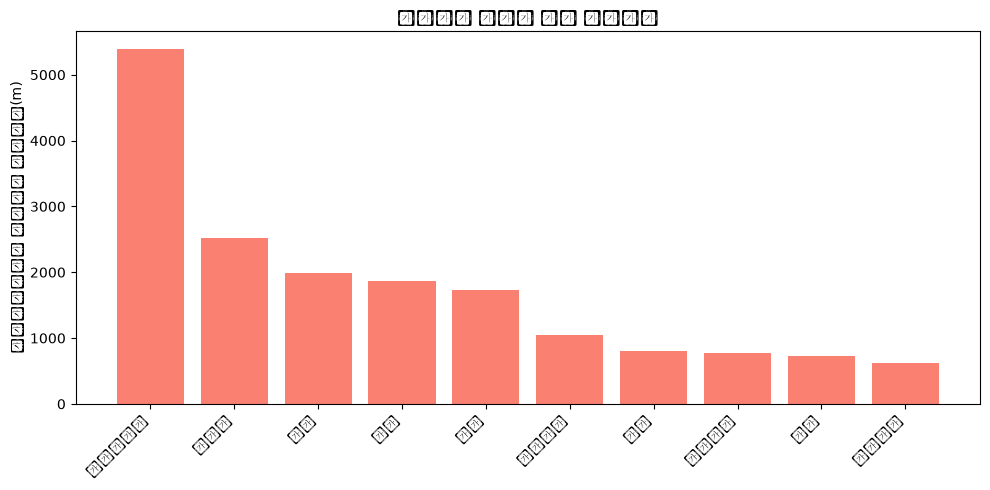

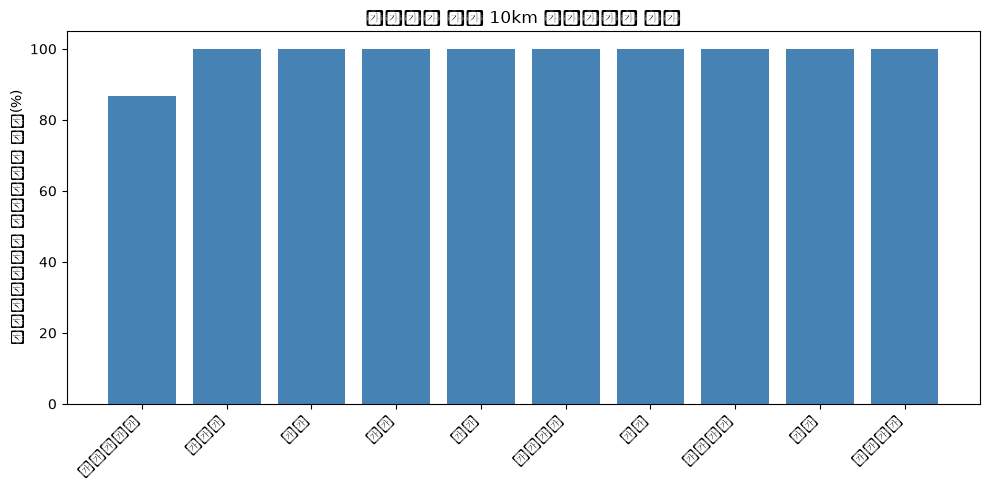

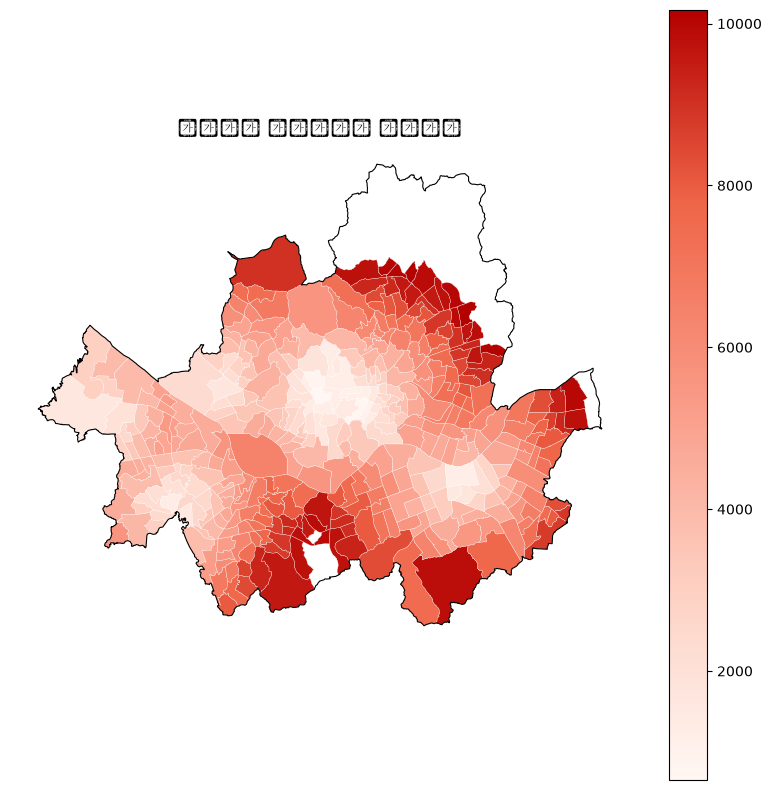

In [12]:
bound_map = bound.to_crs("EPSG:5179")

category_dong_summary_plot = category_dong_summary.sort_values(
    "평균_문화누리대상자_가중평균_접근거리_m",
    ascending=False
)

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(
    category_dong_summary_plot["중분류"],
    category_dong_summary_plot["평균_문화누리대상자_가중평균_접근거리_m"],
    color="salmon"
)
ax.set_title("중분류별 행정동 평균 접근거리", fontsize=12)
ax.set_xlabel("")
ax.set_ylabel("문화누리대상자 가중평균 접근거리(m)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig(
    IMAGE_PATH / "공공기관식_문화시설_중분류별_접근거리_비교.png",
    bbox_inches="tight",
    pad_inches=0.1,
    dpi=240
)
plt.show()

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(
    category_dong_summary_plot["중분류"],
    category_dong_summary_plot["평균_서비스권역비율"],
    color="steelblue"
)
ax.set_title("중분류별 평균 10km 서비스권역 비율", fontsize=12)
ax.set_xlabel("")
ax.set_ylabel("문화누리대상자 서비스권역 비율(%)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig(
    IMAGE_PATH / "공공기관식_문화시설_중분류별_서비스권역비율_비교.png",
    bbox_inches="tight",
    pad_inches=0.1,
    dpi=240
)
plt.show()

worst_category = category_dong_summary_plot.iloc[0]["중분류"]
public_access_dong_map = bound_map.merge(
    public_access_dong[public_access_dong["중분류"] == worst_category],
    on=["시군구", "행정동"],
    how="left"
)

fig, ax = plt.subplots(figsize=(10, 10))
public_access_dong_map.plot(
    column="문화누리대상자_가중평균_접근거리_m",
    cmap=salmon_cmap,
    edgecolor="white",
    linewidth=0.2,
    legend=True,
    ax=ax
)
bound_map.dissolve().boundary.plot(ax=ax, color="black", linewidth=0.8)
ax.set_title(f"행정동별 {worst_category} 접근거리", fontsize=13)
ax.set_axis_off()
plt.savefig(
    IMAGE_PATH / f"공공기관식_문화시설_{worst_category}_접근거리_행정동.png",
    bbox_inches="tight",
    pad_inches=0.1,
    dpi=240
)
plt.show()

## 산출물 저장

중분류별 격자 접근성 테이블과 행정동 접근성 지표를 저장한다.
`GRID_CD + 중분류`, `시군구 + 행정동 + 중분류`가 각각의 분석 키다.

In [13]:
public_access_dong_map_all = bound_map.merge(
    public_access_dong,
    on=["시군구", "행정동"],
    how="left"
)

public_access_grid.to_file(
    NOTEBOOK_OUTPUT_PATH / "공공기관식_문화시설_중분류별_접근성_격자.gpkg",
    driver="GPKG"
)

public_access_grid.drop(columns="geometry").to_csv(
    NOTEBOOK_OUTPUT_PATH / "공공기관식_문화시설_중분류별_접근성_격자.csv",
    index=False,
    encoding="utf-8-sig"
)

public_access_dong.to_csv(
    NOTEBOOK_OUTPUT_PATH / "공공기관식_문화시설_중분류별_접근성_행정동.csv",
    index=False,
    encoding="utf-8-sig"
)

public_access_dong_map_all.to_file(
    NOTEBOOK_OUTPUT_PATH / "공공기관식_문화시설_중분류별_접근성_행정동.gpkg",
    driver="GPKG"
)

category_access_summary.to_csv(
    NOTEBOOK_OUTPUT_PATH / "공공기관식_문화시설_중분류별_계산요약.csv",
    index=False,
    encoding="utf-8-sig"
)

category_dong_summary.to_csv(
    NOTEBOOK_OUTPUT_PATH / "공공기관식_문화시설_중분류별_행정동요약.csv",
    index=False,
    encoding="utf-8-sig"
)

print("저장 완료")
print(NOTEBOOK_OUTPUT_PATH / "공공기관식_문화시설_중분류별_접근성_격자.gpkg")
print(NOTEBOOK_OUTPUT_PATH / "공공기관식_문화시설_중분류별_접근성_격자.csv")
print(NOTEBOOK_OUTPUT_PATH / "공공기관식_문화시설_중분류별_접근성_행정동.csv")
print(NOTEBOOK_OUTPUT_PATH / "공공기관식_문화시설_중분류별_접근성_행정동.gpkg")
print(NOTEBOOK_OUTPUT_PATH / "공공기관식_문화시설_중분류별_계산요약.csv")
print(NOTEBOOK_OUTPUT_PATH / "공공기관식_문화시설_중분류별_행정동요약.csv")

저장 완료
C:\project\oracle_mnc_project\notebooks\access\OUTPUT\공공기관식_문화시설_중분류별_접근성_격자.gpkg
C:\project\oracle_mnc_project\notebooks\access\OUTPUT\공공기관식_문화시설_중분류별_접근성_격자.csv
C:\project\oracle_mnc_project\notebooks\access\OUTPUT\공공기관식_문화시설_중분류별_접근성_행정동.csv
C:\project\oracle_mnc_project\notebooks\access\OUTPUT\공공기관식_문화시설_중분류별_접근성_행정동.gpkg
C:\project\oracle_mnc_project\notebooks\access\OUTPUT\공공기관식_문화시설_중분류별_계산요약.csv
C:\project\oracle_mnc_project\notebooks\access\OUTPUT\공공기관식_문화시설_중분류별_행정동요약.csv


## 최종 점검

산출물 레코드 수, 분석 키 중복, 접근거리 결측, 음수 거리, 중분류별 문화누리대상자 총량 보존 여부를 마지막으로 확인한다.

In [14]:
print(f"격자-중분류 산출물 레코드 수: {len(public_access_grid):,}")
print(f"행정동-중분류 산출물 레코드 수: {len(public_access_dong):,}")
print(f"격자-중분류 키 중복: {public_access_grid[['GRID_CD', '중분류']].duplicated().sum()}")
print(f"행정동-중분류 키 중복: {public_access_dong[['시군구', '행정동', '중분류']].duplicated().sum()}")
print(f"최근접 가맹점 ID 결측: {public_access_grid['최근접_가맹점_ID'].isna().sum()}")
print(f"문화시설 접근거리 음수: {(public_access_grid['문화시설_접근거리_m'] < 0).sum()}")

target_total = grid["문화누리대상자_추정_인구수"].sum()
target_by_category_grid = public_access_grid.groupby("중분류")["문화누리대상자_추정_인구수"].sum()
target_by_category_dong = public_access_dong.groupby("중분류")["문화누리대상자_추정_인구수"].sum()

print(f"기준 문화누리대상자 추정 인구수 합: {target_total:,.6f}")
print("\n격자 산출물 중분류별 문화누리대상자 추정 인구수 합 차이")
print((target_by_category_grid - target_total).round(8))
print("\n행정동 산출물 중분류별 문화누리대상자 추정 인구수 합 차이")
print((target_by_category_dong - target_total).round(8))

print("\n접근성 하위 행정동-중분류")
display(
    public_access_dong
    .sort_values("문화누리대상자_가중평균_접근거리_m", ascending=False)
    .head(10)
)

print("\n서비스권역비율 하위 행정동-중분류")
display(
    public_access_dong
    .sort_values("문화누리대상자_서비스권역비율", ascending=True)
    .head(10)
)

격자-중분류 산출물 레코드 수: 605,280
행정동-중분류 산출물 레코드 수: 4,260


격자-중분류 키 중복: 0
행정동-중분류 키 중복: 0
최근접 가맹점 ID 결측: 12163
문화시설 접근거리 음수: 0
기준 문화누리대상자 추정 인구수 합: 582,549.000000

격자 산출물 중분류별 문화누리대상자 추정 인구수 합 차이
중분류
공연       0
관광지      0
도서       0
문화체험     0
미술       0
스포츠관람    0
영상       0
음악       0
체육시설     0
체육용품     0
Name: 문화누리대상자_추정_인구수, dtype: int64

행정동 산출물 중분류별 문화누리대상자 추정 인구수 합 차이
중분류
공연       0
관광지      0
도서       0
문화체험     0
미술       0
스포츠관람    0
영상       0
음악       0
체육시설     0
체육용품     0
Name: 문화누리대상자_추정_인구수, dtype: int64

접근성 하위 행정동-중분류


,시군구,행정동,중분류,격자수,문화누리대상자_추정_인구수,10km_서비스권역_문화누리대상자수,문화누리대상자_서비스권역비율,문화시설_접근거리_평균_m,문화시설_접근거리_중앙값_m,문화시설_접근거리_최소_m,문화시설_접근거리_최대_m,문화누리대상자_가중평균_접근거리_m
4185,중랑구,묵1동,스포츠관람,122,1904,14,0.735294,10132.829902,10076.415351,9982.351573,10339.722782,10167.759649
1665,도봉구,창3동,스포츠관람,67,1961,0,0.000000,10088.714810,10088.714810,10039.742840,10137.686780,10137.686780
4105,중랑구,망우3동,스포츠관람,95,2728,0,0.000000,10083.135564,10083.135564,10034.141624,10132.129504,10099.169945
515,강북구,수유3동,스포츠관람,75,2463,109,4.425497,10025.212101,10029.547538,9900.668351,10137.178004,10038.239797
425,강북구,번1동,스포츠관람,63,1832,5,0.272926,9999.523378,10029.849494,9916.948118,10051.772521,10028.877280
1365,노원구,공릉1동,스포츠관람,124,3388,20,0.590319,9973.893410,10012.232280,9732.408701,10077.346180,10001.696664
245,강동구,고덕2동,스포츠관람,243,826,0,0.000000,9960.779081,9997.405350,9816.137471,10063.844232,9960.779081
1865,동작구,사당1동,스포츠관람,65,1097,60,5.469462,9905.265889,9922.566599,9750.626927,10043.110762,9922.735202
1475,노원구,월계2동,스포츠관람,201,3842,706,18.375846,9882.729254,9936.300141,9376.116668,10104.434995,9898.449414
4195,중랑구,묵2동,스포츠관람,66,1614,389,24.101611,9880.397781,9911.075882,9596.663083,10067.838699,9889.643633



서비스권역비율 하위 행정동-중분류


,시군구,행정동,중분류,격자수,문화누리대상자_추정_인구수,10km_서비스권역_문화누리대상자수,문화누리대상자_서비스권역비율,문화시설_접근거리_평균_m,문화시설_접근거리_중앙값_m,문화시설_접근거리_최소_m,문화시설_접근거리_최대_m,문화누리대상자_가중평균_접근거리_m
4225,중랑구,신내1동,스포츠관람,255,3601,0,0.0,NaN,NaN,NaN,NaN,NaN
4235,중랑구,신내2동,스포츠관람,90,1872,0,0.0,NaN,NaN,NaN,NaN,NaN
4105,중랑구,망우3동,스포츠관람,95,2728,0,0.0,10083.135564,10083.135564,10034.141624,10132.129504,10099.169945
4115,중랑구,망우본동,스포츠관람,296,3864,0,0.0,NaN,NaN,NaN,NaN,NaN
1605,도봉구,쌍문1동,스포츠관람,117,2145,0,0.0,NaN,NaN,NaN,NaN,NaN
1615,도봉구,쌍문2동,스포츠관람,58,2031,0,0.0,NaN,NaN,NaN,NaN,NaN
1585,도봉구,방학2동,스포츠관람,110,4209,0,0.0,NaN,NaN,NaN,NaN,NaN
1595,도봉구,방학3동,스포츠관람,193,895,0,0.0,NaN,NaN,NaN,NaN,NaN
1575,도봉구,방학1동,스포츠관람,104,2892,0,0.0,NaN,NaN,NaN,NaN,NaN
1555,도봉구,도봉1동,스포츠관람,842,2716,0,0.0,NaN,NaN,NaN,NaN,NaN
